In [3]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt
import torch

from train import Trainer, TrainingConfig
from train.trainer import decode_angle, circular_angle_error

print("Imports OK")
print(f"PyTorch {torch.__version__}")

# Confirm device
if torch.backends.mps.is_available():
    print("Device: MPS (Apple GPU)")
elif torch.cuda.is_available():
    print(f"Device: CUDA ({torch.cuda.get_device_name(0)})")
else:
    print("Device: CPU")

Imports OK
PyTorch 2.10.0
Device: MPS (Apple GPU)


In [4]:
# Load dataset
data = np.load("../data/shared_ring_dataset.npz", allow_pickle=True)

OBS_LEVELS = {
    "100%": ("X_rates_obs_100", 1.0),
    "50%":  ("X_rates_obs_50",  0.5),
    "25%":  ("X_rates_obs_25",  0.25),
    "10%":  ("X_rates_obs_10",  0.1),
}

Y       = data["Y_rates"]    # (trials, bins, neurons)
Y_theta = data["Y_theta"]    # (trials, bins)
train_idx = data["train_idx"]
test_idx  = data["test_idx"]

print(f"Y shape:      {Y.shape}")
print(f"Y_theta shape:{Y_theta.shape}")
print(f"Train trials: {len(train_idx)}   Test trials: {len(test_idx)}")
print(f"Obs levels:   {list(OBS_LEVELS.keys())}")

Y shape:      (140, 1000, 100)
Y_theta shape:(140, 1000)
Train trials: 112   Test trials: 28
Obs levels:   ['100%', '50%', '25%', '10%']


In [34]:
# Training config
# Increase n_epochs to 500-1000 for a thorough overnight run.
train_config = TrainingConfig(
    model_type="vanilla",
    hidden_dim=100,
    alpha=0.5,
    learning_rate=1e-3,
    n_epochs=2000, # Prev 300
    clip_grad=1.0,
    checkpoint_dir="../checkpoints/vanilla_nextstep",
    checkpoint_every=50,
    keep_last_n=3,
    log_every=25,
    device="auto",
)

print(train_config)

TrainingConfig(model_type='vanilla', hidden_dim=100, alpha=0.5, rank=2, learning_rate=0.001, n_epochs=2000, clip_grad=1.0, checkpoint_dir='../checkpoints/vanilla_nextstep', checkpoint_every=50, keep_last_n=3, log_every=25, device='auto')


In [35]:
# Run training for all observation levels — NEXT-STEP PREDICTION
#
# X[:, :-1, :] = observed partial rates at time t      (input)
# Y[:, 1:,  :] = full rates at time t+1                (target)
#
# This forces the model to learn temporal dynamics: to predict the future
# population state from the past partial observation. A model that has
# learned ring attractor dynamics will do this correctly by knowing that
# the bump moves continuously; a model without ring dynamics cannot.

results   = {}
Y_theta_test = Y_theta[test_idx][:, 1:]  # shifted by 1 to match target

for label, (x_key, obs_frac) in OBS_LEVELS.items():
    print(f"\n{'='*55}")
    print(f"Observation level: {label}")
    print(f"{'='*55}")

    X = data[x_key]          # (trials, 1000, k_neurons)
    X_in  = X[:, :-1, :]    # input:  t = 0..998   shape (trials, 999, k)
    Y_out = Y[:, 1:,  :]    # target: t = 1..999   shape (trials, 999, 100)

    trainer = Trainer(train_config)
    result = trainer.train(
        X_train=X_in[train_idx],
        Y_train=Y_out[train_idx],
        X_test=X_in[test_idx],
        Y_test=Y_out[test_idx],
        Y_theta_test=Y_theta_test,
        observation_level=obs_frac,
    )

    results[label] = result


Observation level: 100%
Training vanilla RNN on mps
  Input dim: 100, Hidden dim: 100, Output dim: 100
  Epochs: 0 -> 2000

  Epoch    1/2000  train_loss=7.907260  test_loss=7.348999  *best*
  Epoch   25/2000  train_loss=3.750395  test_loss=3.649471  *best*
  Epoch   50/2000  train_loss=2.723126  test_loss=2.701400  *best*
  Saved checkpoint: vanilla_obs100_epoch0050_20260321_201717.pt
  Epoch   75/2000  train_loss=2.339940  test_loss=2.334060  *best*
  Epoch  100/2000  train_loss=2.157538  test_loss=2.155929  *best*
  Saved checkpoint: vanilla_obs100_epoch0100_20260321_201734.pt
  Epoch  125/2000  train_loss=2.045051  test_loss=2.045334  *best*
  Epoch  150/2000  train_loss=1.964007  test_loss=1.963991  *best*
  Saved checkpoint: vanilla_obs100_epoch0150_20260321_201750.pt
  Epoch  175/2000  train_loss=1.904279  test_loss=1.903123  *best*
  Epoch  200/2000  train_loss=1.859631  test_loss=1.857540  *best*
  Saved checkpoint: vanilla_obs100_epoch0200_20260321_201807.pt
  Epoch  225/200

In [36]:
# Summary table
import pandas as pd

rows = []
for label, r in results.items():
    rows.append({
        "obs_level": label,
        "train_mse": f"{r.final_train_mse:.6f}",
        "test_mse":  f"{r.final_test_mse:.6f}",
        "angle_err_rad": f"{r.angle_error:.4f}",
        "angle_err_deg": f"{np.degrees(r.angle_error):.2f}",
        "train_time_s":  f"{r.training_time:.1f}",
    })

pd.DataFrame(rows)

,obs_level,train_mse,test_mse,angle_err_rad,angle_err_deg,train_time_s
0,100%,1.293825,1.301884,0.2826,16.19,669.6
1,50%,1.564661,1.576386,0.2717,15.57,2681.2
2,25%,1.716335,1.804315,0.2986,17.11,663.5
3,10%,1.815487,1.876628,0.3044,17.44,1573.1


In [16]:
# Resuming to 2000 epochs?
train_config_2000 = TrainingConfig(
    model_type="vanilla",
    hidden_dim=100,
    alpha=0.1,
    learning_rate=1e-3,
    n_epochs=2000,
    clip_grad=1.0,
    checkpoint_dir="../checkpoints/vanilla",
    checkpoint_every=50,
    keep_last_n=3,
    log_every=25,
    device="auto",
)

# Resume all 4 obs levels from their best checkpoints
for label, (x_key, obs_frac) in OBS_LEVELS.items():
    obs_pct = int(obs_frac * 100)
    ckpt = f"../checkpoints/vanilla/vanilla_obs{obs_pct}_best.pt"
    
    X = data[x_key]
    trainer = Trainer(train_config_2000)  # same config but n_epochs=2000
    trainer.resume_from_checkpoint(ckpt, input_dim=X.shape[-1], output_dim=Y.shape[-1])
    result = trainer.train(X[train_idx], Y[train_idx], X[test_idx], Y[test_idx],
                           Y_theta_test, observation_level=obs_frac)
    results[label] = result

Resumed from checkpoint: epoch 300, best test loss 1.821988
Training vanilla RNN on mps
  Input dim: 100, Hidden dim: 100, Output dim: 100
  Epochs: 300 -> 2000

  Epoch  325/2000  train_loss=1.809757  test_loss=1.806712  *best*
  Epoch  350/2000  train_loss=1.796272  test_loss=1.792769  *best*
  Saved checkpoint: vanilla_obs100_epoch0350_20260321_143538.pt
  Epoch  375/2000  train_loss=1.783660  test_loss=1.779905  *best*
  Epoch  400/2000  train_loss=1.771718  test_loss=1.767869  *best*
  Saved checkpoint: vanilla_obs100_epoch0400_20260321_143555.pt
  Epoch  425/2000  train_loss=1.760293  test_loss=1.756458  *best*
  Epoch  450/2000  train_loss=1.749173  test_loss=1.745358  *best*
  Saved checkpoint: vanilla_obs100_epoch0450_20260321_143611.pt
  Epoch  475/2000  train_loss=1.738294  test_loss=1.734495  *best*
  Epoch  500/2000  train_loss=1.727559  test_loss=1.723817  *best*
  Saved checkpoint: vanilla_obs100_epoch0500_20260321_143628.pt
  Epoch  525/2000  train_loss=1.716981  test_l

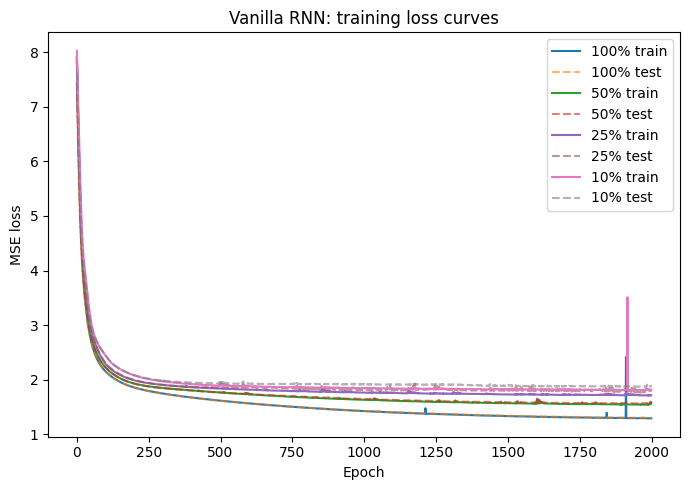

In [37]:
# Training loss curves for all observation levels
plt.figure(figsize=(7, 5))
for label, r in results.items():
    plt.plot(r.train_losses, label=f"{label} train")
    plt.plot(r.test_losses,  label=f"{label} test", linestyle="--", alpha=0.6)
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Vanilla RNN: training loss curves")
plt.legend()
plt.tight_layout()
plt.show()

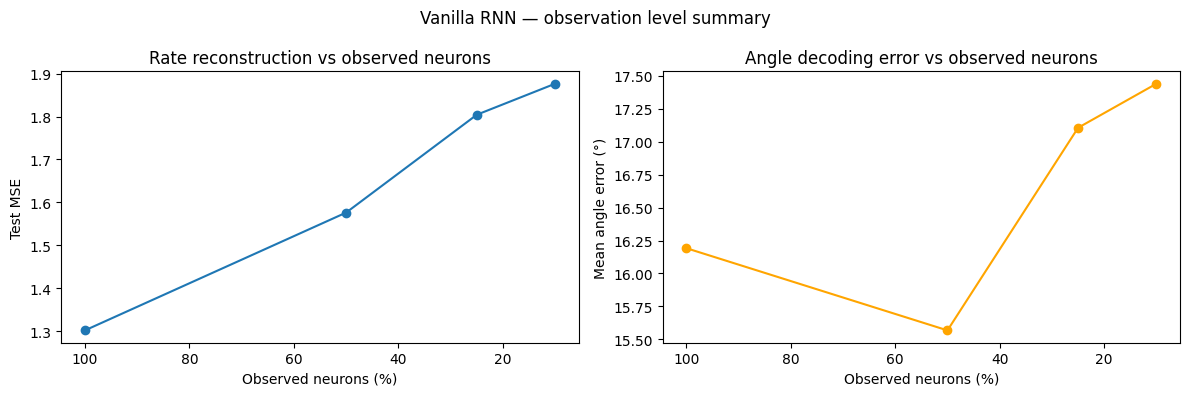

In [38]:
# Test MSE and angle error vs observed neuron fraction
obs_numeric  = [100, 50, 25, 10]
test_mse_vals  = [results[k].final_test_mse for k in OBS_LEVELS]
angle_err_vals = [results[k].angle_error    for k in OBS_LEVELS]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(obs_numeric, test_mse_vals, marker="o")
ax1.invert_xaxis()
ax1.set_xlabel("Observed neurons (%)")
ax1.set_ylabel("Test MSE")
ax1.set_title("Rate reconstruction vs observed neurons")

ax2.plot(obs_numeric, np.degrees(angle_err_vals), marker="o", color="orange")
ax2.invert_xaxis()
ax2.set_xlabel("Observed neurons (%)")
ax2.set_ylabel("Mean angle error (°)")
ax2.set_title("Angle decoding error vs observed neurons")

plt.suptitle("Vanilla RNN — observation level summary")
plt.tight_layout()
plt.show()

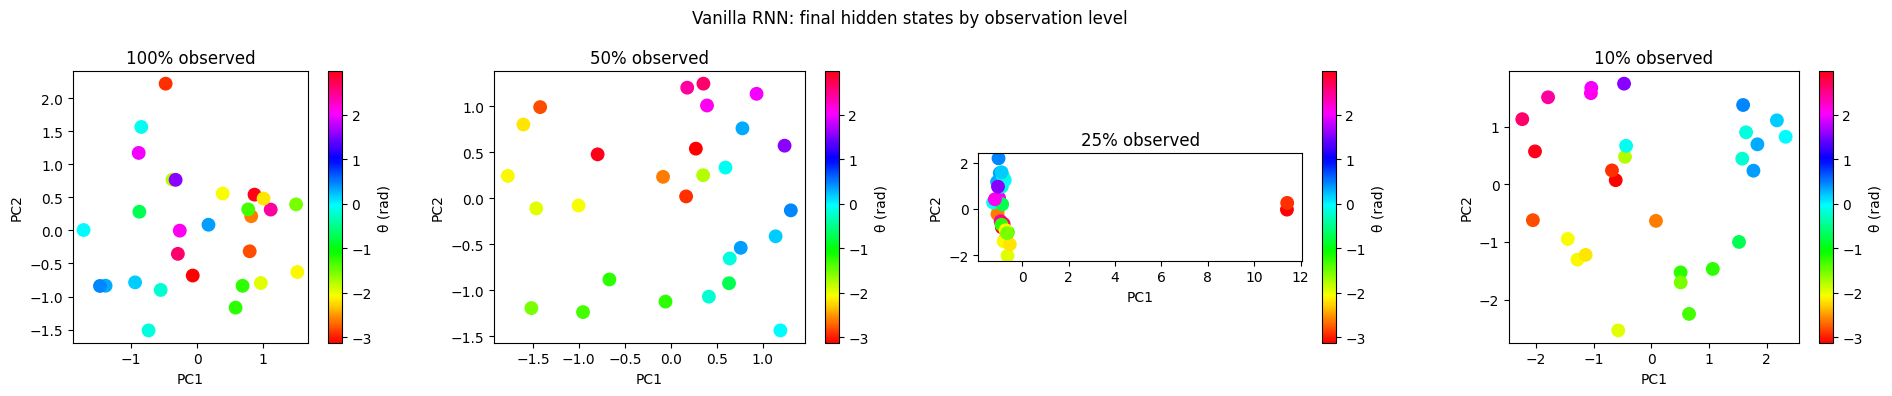

In [39]:
# Hidden state PCA — one plot per observation level
# Each dot is one test trial's final hidden state, coloured by its last decoded angle.
from sklearn.decomposition import PCA

fig, axes = plt.subplots(1, len(OBS_LEVELS), figsize=(5 * len(OBS_LEVELS), 4))

for ax, (label, r) in zip(axes, results.items()):
    h_last      = r.hidden_states_test[:, -1, :]   # (n_test, hidden_dim)
    theta_last  = Y_theta_test[:, -1]              # (n_test,)

    pca = PCA(n_components=2)
    h_pca = pca.fit_transform(h_last)

    sc = ax.scatter(h_pca[:, 0], h_pca[:, 1], c=theta_last, cmap="hsv", s=80)
    ax.set_title(f"{label} observed")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_aspect("equal")
    plt.colorbar(sc, ax=ax, label="θ (rad)")

plt.suptitle("Vanilla RNN: final hidden states by observation level")
plt.tight_layout()
plt.show()

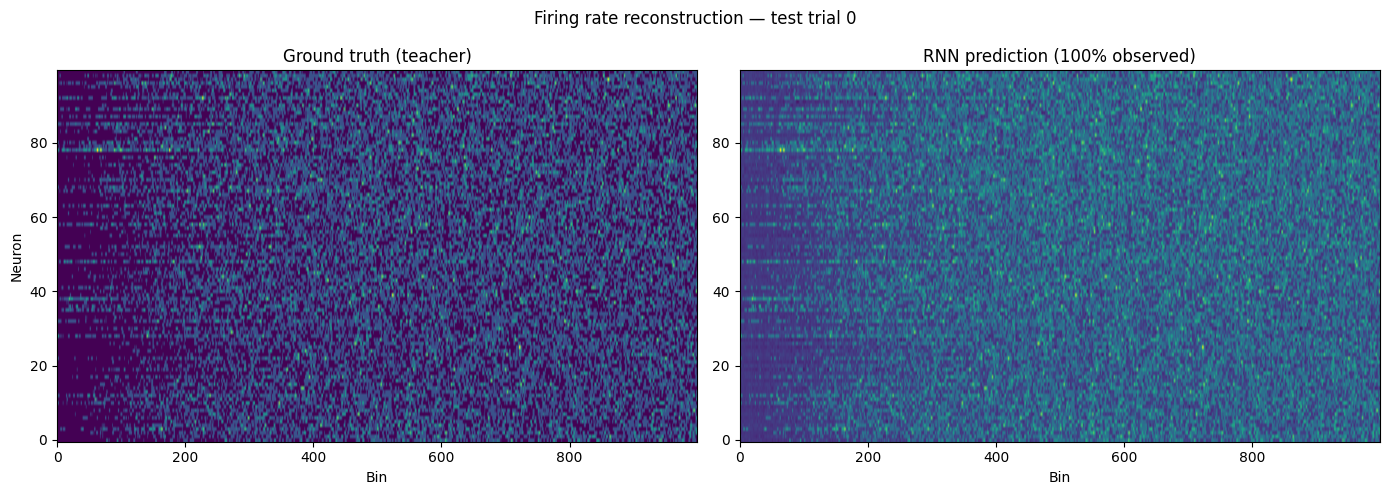

In [29]:
# Reconstruction heatmap: ground truth vs predicted rates for one trial
selected_level = "100%"
trial_idx = 0

Y_test = Y[test_idx]   # (n_test, bins, neurons)
y_pred = results[selected_level].predictions_test   # (n_test, bins, neurons)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.imshow(Y_test[trial_idx].T, aspect="auto", origin="lower", cmap="viridis")
ax1.set_title("Ground truth (teacher)")
ax1.set_xlabel("Bin")
ax1.set_ylabel("Neuron")

ax2.imshow(y_pred[trial_idx].T, aspect="auto", origin="lower", cmap="viridis")
ax2.set_title(f"RNN prediction ({selected_level} observed)")
ax2.set_xlabel("Bin")

plt.suptitle(f"Firing rate reconstruction — test trial {trial_idx}")
plt.tight_layout()
plt.show()

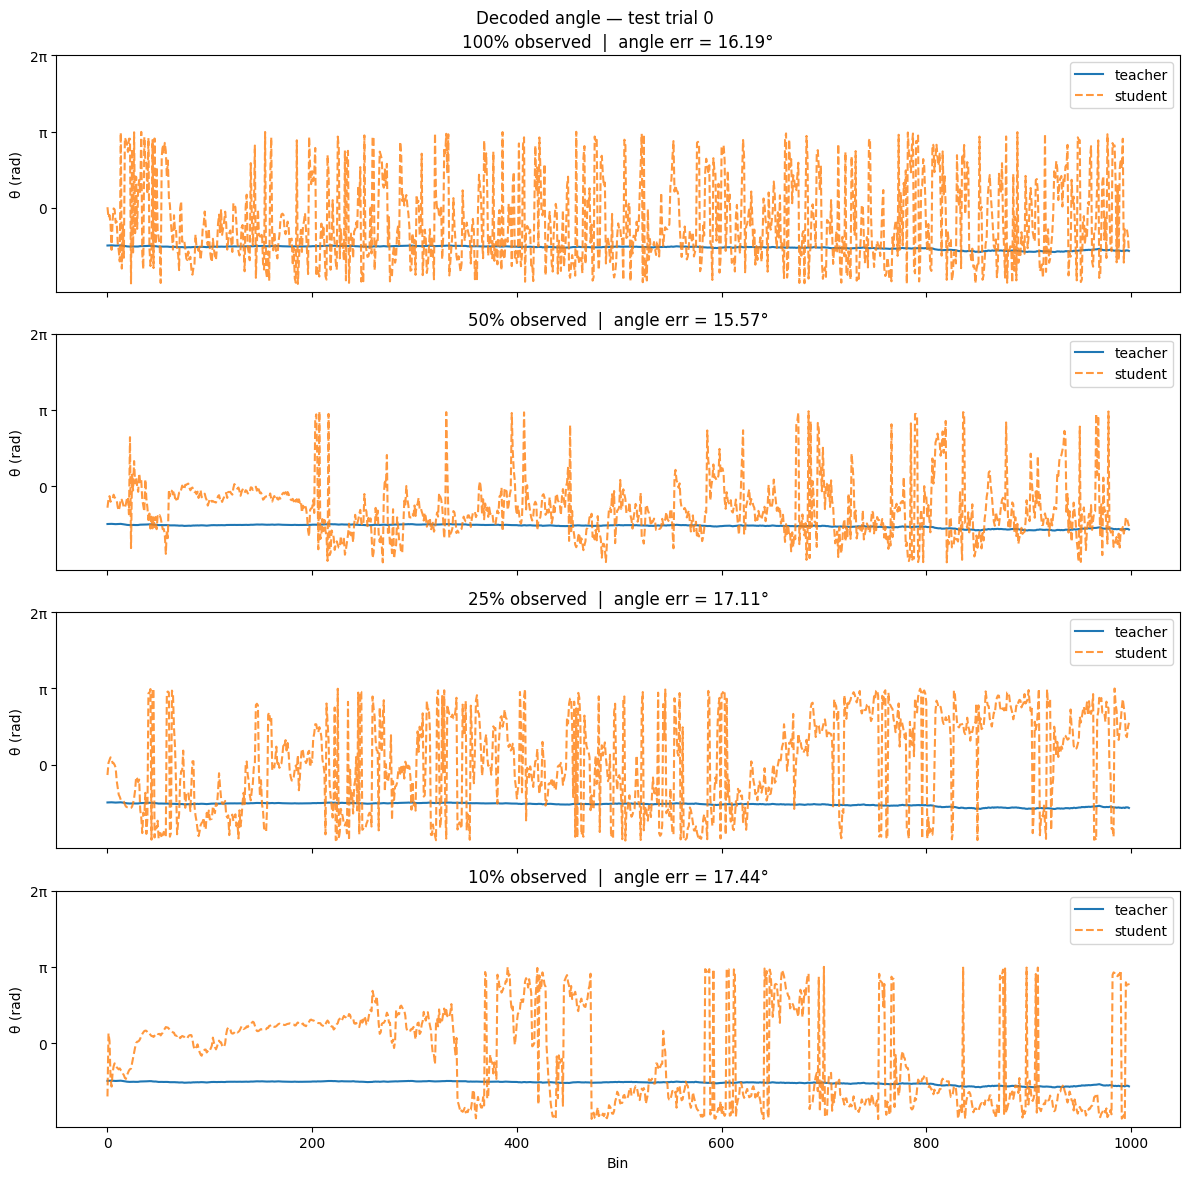

In [40]:
# Predicted vs true angle over time — one panel per observation level
trial_idx = 0

fig, axes = plt.subplots(len(OBS_LEVELS), 1, figsize=(12, 3 * len(OBS_LEVELS)), sharex=True)

for ax, (label, r) in zip(axes, results.items()):
    theta_true = Y_theta_test[trial_idx]      # (bins,)
    theta_pred = r.theta_pred_test[trial_idx] # (bins,)

    ax.plot(theta_true, label="teacher", linewidth=1.5)
    ax.plot(theta_pred, "--", label="student", linewidth=1.5, alpha=0.8)
    ax.set_ylabel("θ (rad)")
    ax.set_title(f"{label} observed  |  angle err = {np.degrees(r.angle_error):.2f}°")
    ax.legend(loc="upper right")
    ax.set_yticks([0, np.pi, 2*np.pi])
    ax.set_yticklabels(["0", "π", "2π"])

axes[-1].set_xlabel("Bin")
plt.suptitle(f"Decoded angle — test trial {trial_idx}")
plt.tight_layout()
plt.show()

In [41]:
import torch

def run_autonomous(model, n_init=300, n_steps=500, h_scale=0.5):
    """
    Run the RNN autonomously (zero input) from many random initial conditions.

    The key test: if the model learned a ring attractor, trajectories starting
    anywhere in state space should converge onto a continuous 1D circle.
    If it learned discrete attractors, trajectories converge to a few clusters.

    Args:
        model:   trained RNN (VanillaRateRNN)
        n_init:  number of random initial hidden states
        n_steps: integration steps with zero input
        h_scale: std of random initial states (keep small to start near origin)

    Returns:
        h_final:  (n_init, hidden_dim)  — converged hidden states
        y_final:  (n_init, output_dim)  — readout rates at convergence
        h_traj:   (n_init, n_steps, hidden_dim)  — full trajectories
    """
    model.eval()
    device = next(model.parameters()).device

    h0 = torch.randn(n_init, model.hidden_dim, device=device) * h_scale
    x_zero = torch.zeros(n_init, n_steps, model.input_dim, device=device)

    with torch.no_grad():
        y_traj, h_traj = model(x_zero, h0=h0)

    return (
        h_traj[:, -1, :].cpu().numpy(),   # converged hidden states
        y_traj[:, -1, :].cpu().numpy(),   # readout at convergence
        h_traj.cpu().numpy(),             # full trajectories
    )

print("run_autonomous() defined.")

run_autonomous() defined.


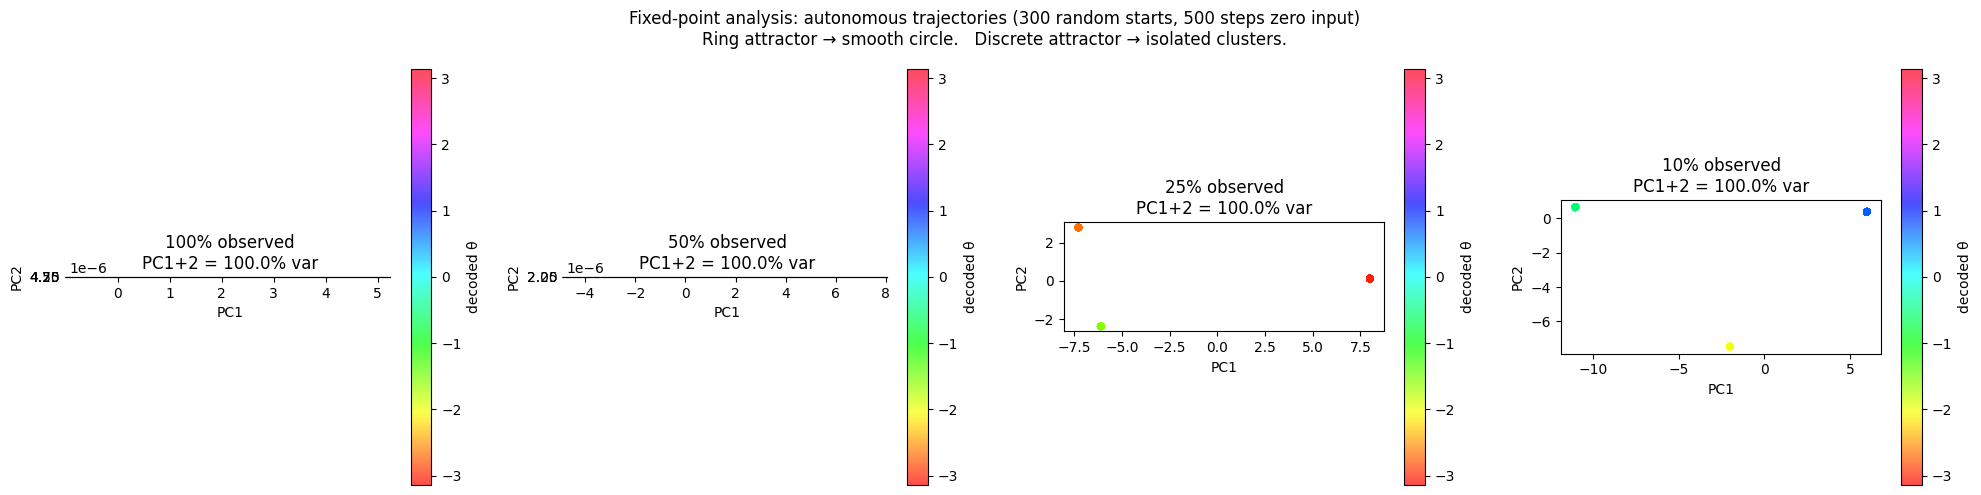

In [42]:
# Fixed-point analysis — PCA of converged autonomous trajectories
# Each dot is one random starting state after running with zero input.
# Ring attractor → dots form a closed circle, smoothly colour-ordered.
# Discrete attractor → dots cluster into a few blobs.

from sklearn.decomposition import PCA

fp_results = {}

fig, axes = plt.subplots(1, len(OBS_LEVELS), figsize=(5 * len(OBS_LEVELS), 5))

for ax, (label, r) in zip(axes, results.items()):
    h_final, y_final, _ = run_autonomous(r.model, n_init=300, n_steps=500)

    # Decode angle from the readout at convergence
    angles = np.linspace(0, 2 * np.pi, y_final.shape[-1], endpoint=False)
    x_pop = (y_final * np.cos(angles)).sum(axis=1)
    y_pop = (y_final * np.sin(angles)).sum(axis=1)
    theta_conv = np.arctan2(y_pop, x_pop)   # decoded angle at convergence

    pca = PCA(n_components=2)
    h_pca = pca.fit_transform(h_final)
    var_explained = pca.explained_variance_ratio_[:2].sum()

    sc = ax.scatter(h_pca[:, 0], h_pca[:, 1],
                    c=theta_conv, cmap="hsv", s=20, alpha=0.7,
                    vmin=-np.pi, vmax=np.pi)
    ax.set_title(f"{label} observed\nPC1+2 = {var_explained:.1%} var")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_aspect("equal")
    plt.colorbar(sc, ax=ax, label="decoded θ")

    fp_results[label] = dict(h_final=h_final, y_final=y_final, theta_conv=theta_conv,
                              h_pca=h_pca, var_explained=var_explained)

plt.suptitle("Fixed-point analysis: autonomous trajectories (300 random starts, 500 steps zero input)\n"
             "Ring attractor → smooth circle.   Discrete attractor → isolated clusters.")
plt.tight_layout()
plt.show()

In [43]:
# Quantitative ring score — three metrics
#
# 1. spread:      mean distance of converged states from the origin.
#                 Near zero → trivial fixed point (input-follower).
#                 Large → model has non-trivial autonomous dynamics.
#
# 2. uniformity:  circular uniformity of decoded angles at convergence.
#                 Uses mean resultant length R ∈ [0,1]:
#                   R=0 → angles are perfectly uniform → ring attractor
#                   R=1 → all angles identical → single fixed point
#                 We report (1 - R) so that 1 = ring-like, 0 = single point.
#
# 3. circularity: aspect ratio of the 2D PCA cloud (min_std / max_std).
#                 Only meaningful when spread is non-trivial.
#                 1 = perfect circle, ~0 = line/degenerate.

rows = []
for label, fp in fp_results.items():
    h_final  = fp["h_final"]
    h_pca    = fp["h_pca"]
    theta_c  = fp["theta_conv"]
    var_2d   = fp["var_explained"]

    # Spread: mean L2 norm of converged states
    spread = np.linalg.norm(h_final, axis=1).mean()

    # Circular uniformity via mean resultant length
    R = np.abs(np.exp(1j * theta_c).mean())   # 0=uniform, 1=all same
    uniformity = 1 - R                         # 1=ring-like, 0=point

    # Circularity: aspect ratio (only sensible when spread > 0.1)
    pc1_std = h_pca[:, 0].std()
    pc2_std = h_pca[:, 1].std()
    circularity = min(pc1_std, pc2_std) / (max(pc1_std, pc2_std) + 1e-8)

    rows.append(dict(
        obs_level=label,
        spread=f"{spread:.3f}",
        uniformity=f"{uniformity:.3f}",
        circularity=f"{circularity:.3f}",
        var_2d=f"{var_2d:.1%}",
    ))
    note = ""
    if spread < 0.05:
        note = "  ← collapsed to origin (pure input-follower)"
    elif uniformity < 0.3:
        note = "  ← discrete fixed points"
    elif uniformity > 0.7 and circularity > 0.5:
        note = "  ← ring-like!"
    print(f"{label:5s}  spread={spread:.3f}  uniformity={uniformity:.3f}  "
          f"circularity={circularity:.3f}  var_2d={var_2d:.1%}{note}")

import pandas as pd
pd.DataFrame(rows)

100%   spread=3.010  uniformity=0.006  circularity=0.000  var_2d=100.0%  ← discrete fixed points
50%    spread=5.821  uniformity=0.060  circularity=0.000  var_2d=100.0%  ← discrete fixed points
25%    spread=7.822  uniformity=0.185  circularity=0.261  var_2d=100.0%  ← discrete fixed points
10%    spread=8.621  uniformity=0.261  circularity=0.241  var_2d=100.0%  ← discrete fixed points


,obs_level,spread,uniformity,circularity,var_2d
0,100%,3.010,0.006,0.000,100.0%
1,50%,5.821,0.060,0.000,100.0%
2,25%,7.822,0.185,0.261,100.0%
3,10%,8.621,0.261,0.241,100.0%
